<a href="https://colab.research.google.com/github/pablomaldonados-dotcom/PABLO/blob/main/Trabajo_IA_Pablo_Maldonado.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Universidad Mayor

## Métodos de Inteligencia Artificial

# Trabajo de Desarrollo Individual

## Clasificación Binaria del Precio de Viviendas mediante Machine Learning

---

**Alumno:** Pablo Maldonado Silva

**Dataset:** datos.csv

---

### Objetivo

Desarrollar distintos modelos de Machine Learning supervisado para clasificar viviendas según su precio de venta utilizando técnicas de clasificación binaria.

# Introducción

En este trabajo se utilizará un conjunto de datos correspondiente al mercado inmobiliario.

La variable objetivo original es **SalePrice**, que representa el precio de venta de cada vivienda.

Como la actividad solicita resolver un problema de **clasificación binaria**, esta variable será transformada en dos categorías:

- Precio Bajo (0)
- Precio Alto (1)

Posteriormente se entrenarán cuatro modelos:

- Regresión Logística con regularización Ridge (L2)
- Random Forest
- XGBoost
- Red Neuronal (MLP)

Finalmente se compararán utilizando Accuracy, Precision, Recall, F1-Score, AUC y KS.

In [1]:
# ==========================================
# IMPORTACIÓN DE LIBRERÍAS
# ==========================================

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

plt.style.use("ggplot")

In [2]:
# ==========================================
# CARGA DEL DATASET
# ==========================================

df = pd.read_csv("datos.csv")

In [3]:
from google.colab import files
import io

print('Por favor, selecciona el archivo datos.csv para cargarlo:')
uploaded = files.upload()

for fn in uploaded.keys():
  print(f'Archivo "{fn}" cargado.')

Por favor, selecciona el archivo datos.csv para cargarlo:


Saving datos.csv to datos (1).csv
Archivo "datos (1).csv" cargado.


In [4]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,YearBuilt,YearRemodAdd,GrLivArea,TotalBsmtSF,BedroomAbvGr,BathroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,GarageCars,GarageArea,SalePrice
0,1,40,RL,83.0,14245,Pave,NaN,Reg,Bnk,1927,2000,932,117,4,1,1,7,3,1233,109270
1,2,20,RL,21.0,5442,Pave,NaN,Reg,Lvl,1924,1973,1733,409,2,1,1,9,2,129,183838
2,3,60,RH,21.0,9431,Pave,NaN,IR2,Bnk,1956,2006,1050,1159,2,1,1,15,2,215,95345
3,4,20,I,178.0,2383,Pave,NaN,Reg,Lvl,2008,2010,886,1808,2,1,1,14,2,692,99505
4,5,90,RL,35.0,8804,Pave,NaN,Reg,Lvl,1909,1989,1018,1335,3,1,1,15,2,23,123899


In [5]:
print("Número de filas:", df.shape[0])
print("Número de columnas:", df.shape[1])

Número de filas: 1460
Número de columnas: 20


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1205 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          135 non-null    object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   YearBuilt      1460 non-null   int64  
 10  YearRemodAdd   1460 non-null   int64  
 11  GrLivArea      1460 non-null   int64  
 12  TotalBsmtSF    1460 non-null   int64  
 13  BedroomAbvGr   1460 non-null   int64  
 14  BathroomAbvGr  1460 non-null   int64  
 15  KitchenAbvGr   1460 non-null   int64  
 16  TotRmsAbvGrd   1460 non-null   int64  
 17  GarageCars     1460 non-null   int64  
 18  GarageAr

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Id,1460.0,730.500000,421.610009,1.0,365.75,730.5,1095.25,1460.0
MSSubClass,1460.0,89.599315,52.266587,20.0,45.00,75.0,120.00,190.0
LotFrontage,1205.0,78.437344,60.920544,21.0,30.00,62.0,104.00,313.0
LotArea,1460.0,9093.674658,6261.262875,1300.0,4133.50,7759.0,12551.75,41455.0
YearBuilt,1460.0,1941.493151,39.894145,1872.0,1909.00,1941.0,1975.00,2010.0
YearRemodAdd,1460.0,1980.036301,17.815002,1950.0,1965.00,1979.0,1995.00,2010.0
GrLivArea,1460.0,1227.530822,939.228566,334.0,496.00,967.5,1631.50,5642.0
TotalBsmtSF,1460.0,864.743151,767.266495,0.0,296.00,654.0,1213.00,5067.0
BedroomAbvGr,1460.0,2.939726,1.016888,1.0,2.00,3.0,3.00,8.0
BathroomAbvGr,1460.0,1.454795,0.715067,0.0,1.00,1.0,2.00,4.0


In [8]:
df.isnull().sum()

,0
Id,0
MSSubClass,0
MSZoning,0
LotFrontage,255
LotArea,0
Street,0
Alley,1325
LotShape,0
LandContour,0
YearBuilt,0


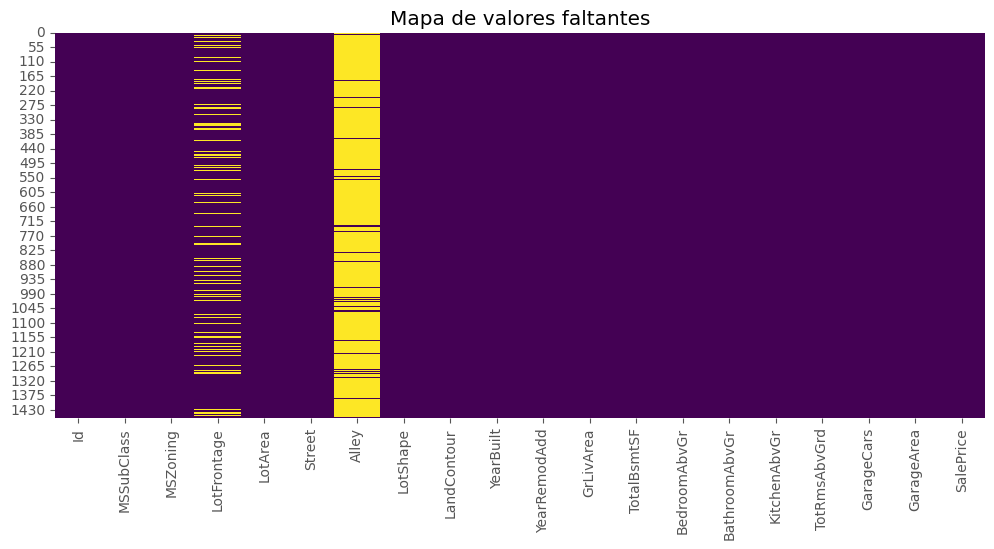

In [9]:
plt.figure(figsize=(12,5))

sns.heatmap(df.isnull(), cmap="viridis", cbar=False)

plt.title("Mapa de valores faltantes")

plt.show()

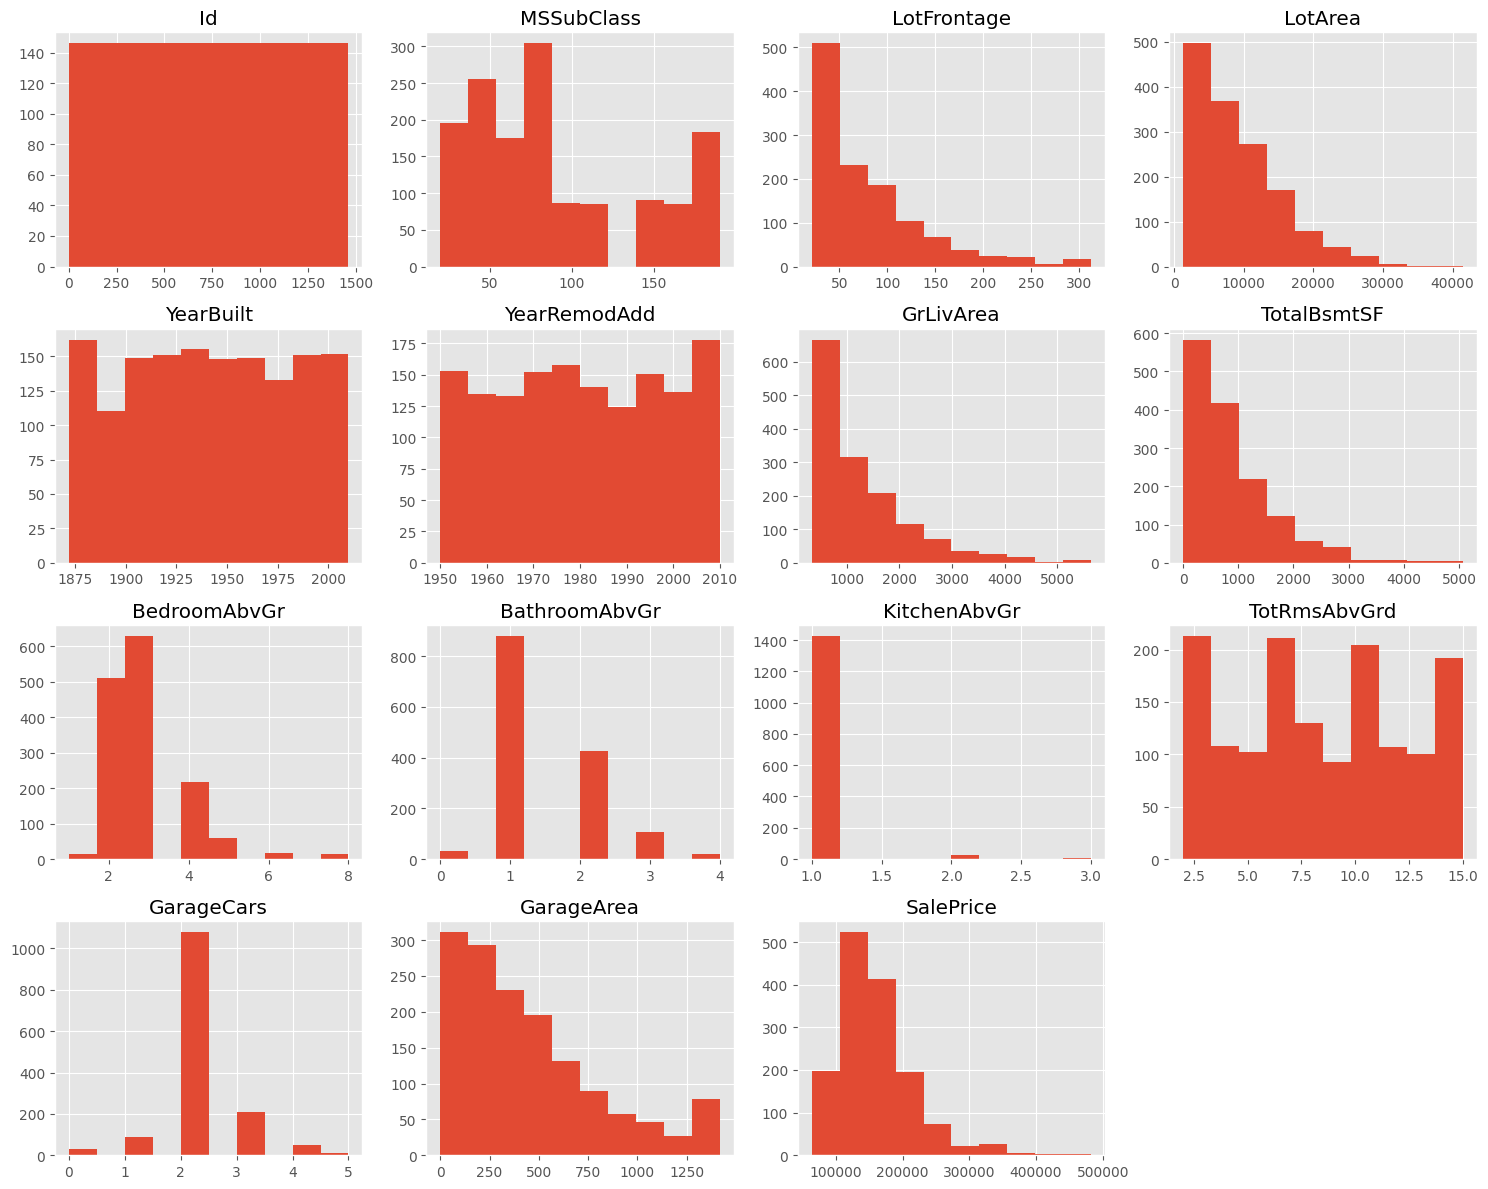

In [10]:
df.hist(figsize=(15,12))

plt.tight_layout()

plt.show()

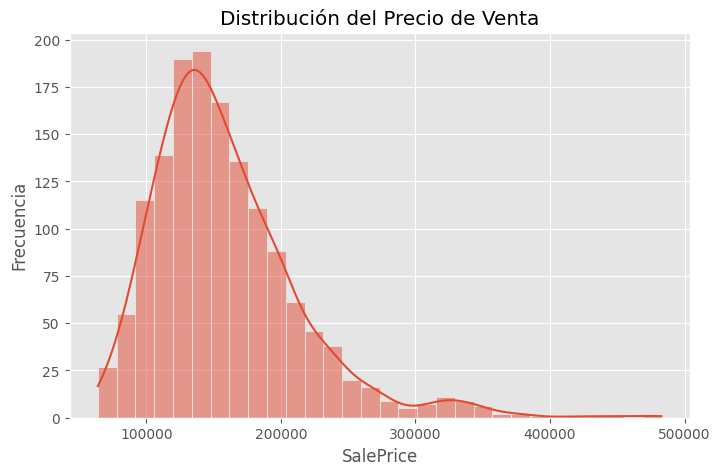

In [11]:
plt.figure(figsize=(8,5))

sns.histplot(df["SalePrice"], bins=30, kde=True)

plt.title("Distribución del Precio de Venta")

plt.xlabel("SalePrice")

plt.ylabel("Frecuencia")

plt.show()

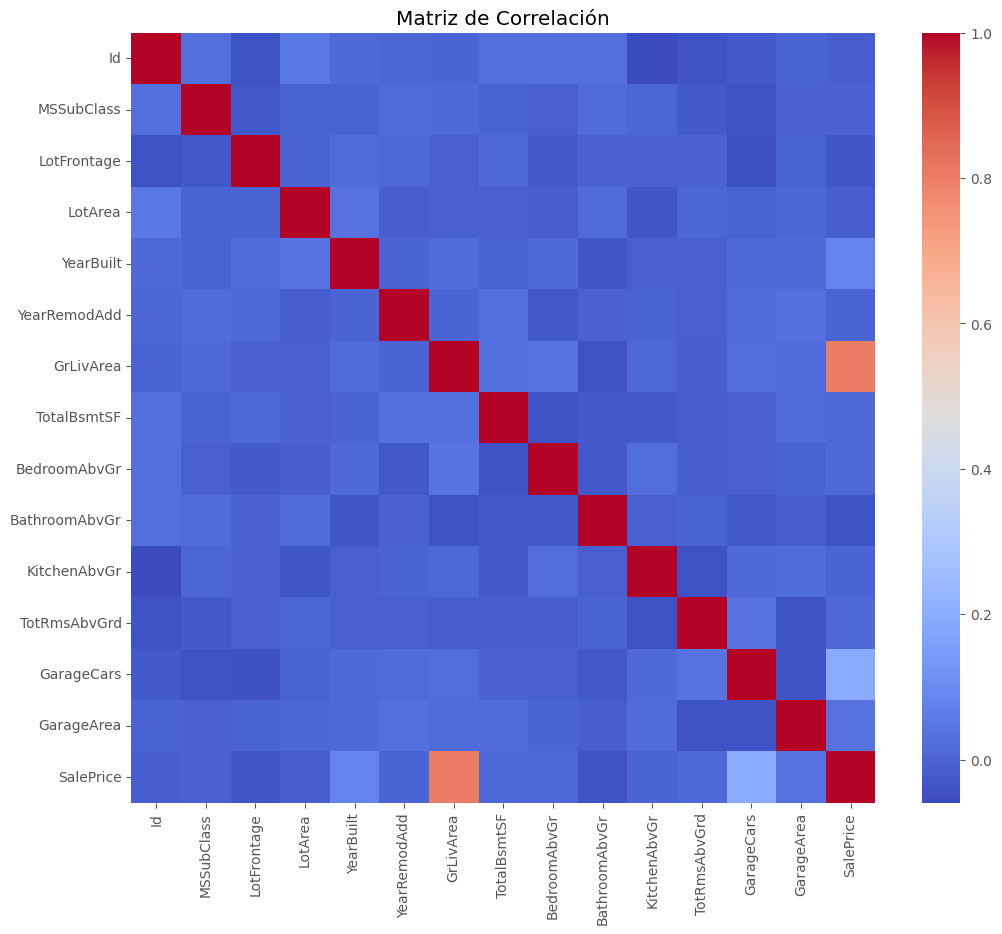

In [12]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(12,10))

sns.heatmap(
    corr,
    cmap="coolwarm",
    annot=False
)

plt.title("Matriz de Correlación")

plt.show()

In [13]:
corr["SalePrice"].sort_values(ascending=False)

,SalePrice
SalePrice,1.000000
GrLivArea,0.802927
GarageCars,0.190959
YearBuilt,0.077484
GarageArea,0.031876
TotRmsAbvGrd,0.011785
TotalBsmtSF,0.010834
BedroomAbvGr,0.008276
KitchenAbvGr,0.002217
YearRemodAdd,0.001165


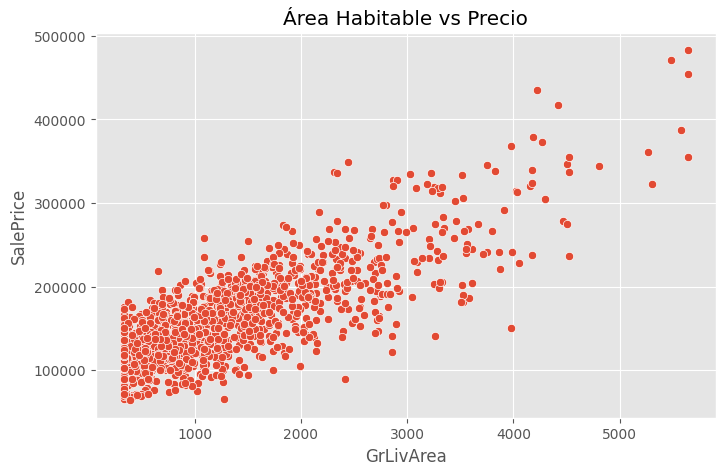

In [14]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="GrLivArea",
    y="SalePrice"
)

plt.title("Área Habitable vs Precio")

plt.show()

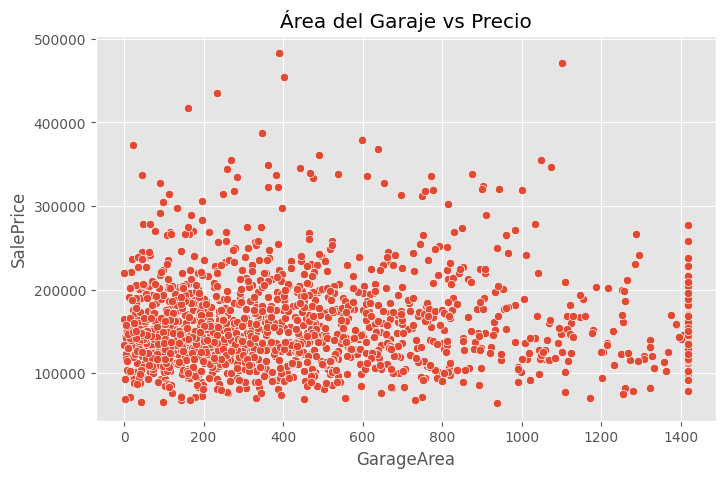

In [15]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="GarageArea",
    y="SalePrice"
)

plt.title("Área del Garaje vs Precio")

plt.show()

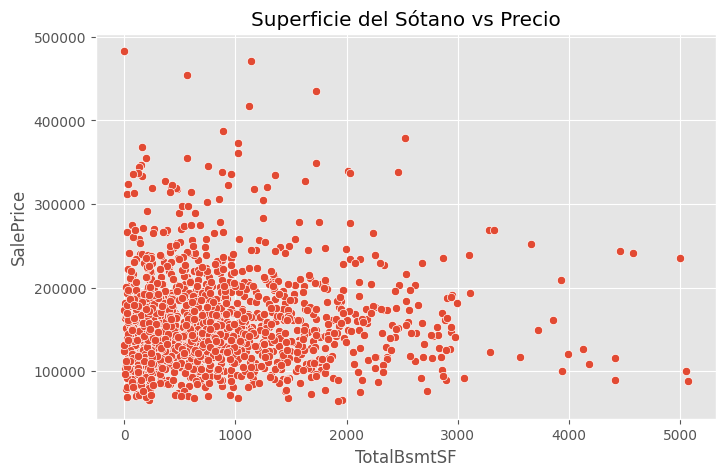

In [16]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="TotalBsmtSF",
    y="SalePrice"
)

plt.title("Superficie del Sótano vs Precio")

plt.show()

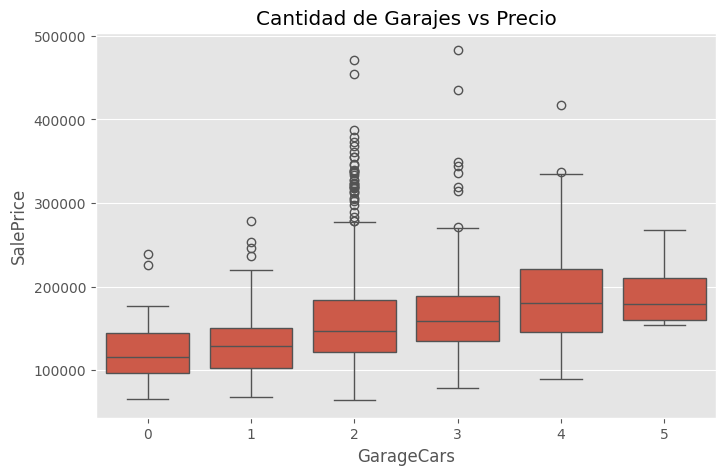

In [17]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="GarageCars",
    y="SalePrice"
)

plt.title("Cantidad de Garajes vs Precio")

plt.show()

In [18]:
df["MSZoning"].value_counts()

,count
MSZoning,
RL,992
I,100
FV,97
RM,92
C,80
RP,46
RH,31
A,22


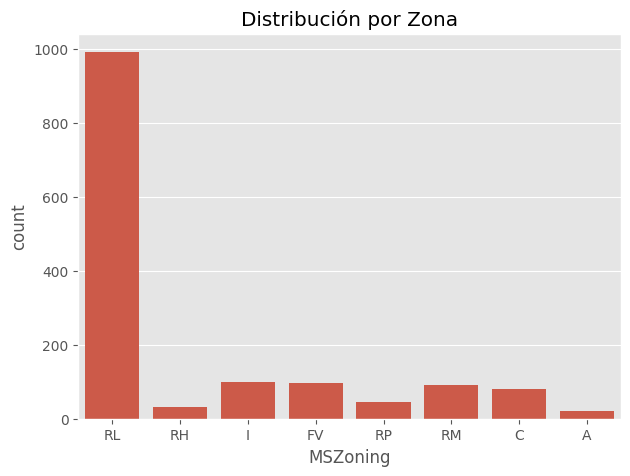

In [19]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="MSZoning"
)

plt.title("Distribución por Zona")

plt.show()

# Conclusiones del análisis exploratorio

El conjunto de datos contiene 1460 registros y 20 variables, incluyendo variables numéricas y categóricas. La exploración muestra que características como el área habitable (`GrLivArea`), el tamaño del sótano (`TotalBsmtSF`) y la capacidad del garaje (`GarageCars`) presentan una relación positiva con el precio de venta. También se identificó la presencia de algunas variables categóricas que requerirán codificación antes del entrenamiento de los modelos.

En la siguiente sección se prepararán los datos para el proceso de clasificación binaria.

# Preparación de los datos

Antes de entrenar los modelos de Machine Learning es necesario preparar los datos. En esta etapa se realizará la creación de la variable objetivo binaria, el tratamiento de valores faltantes, la codificación de variables categóricas y la normalización de los datos cuando sea necesario.

In [20]:
# ==========================================
# CREACIÓN DE LA VARIABLE OBJETIVO
# ==========================================

mediana = df["SalePrice"].median()

print("Mediana del precio:", mediana)

Mediana del precio: 148140.0


In [21]:
df["Precio_Alto"] = (df["SalePrice"] > mediana).astype(int)

df[["SalePrice", "Precio_Alto"]].head()

,SalePrice,Precio_Alto
0,109270,0
1,183838,1
2,95345,0
3,99505,0
4,123899,0


In [22]:
df["Precio_Alto"].value_counts()

,count
Precio_Alto,
0,730
1,730


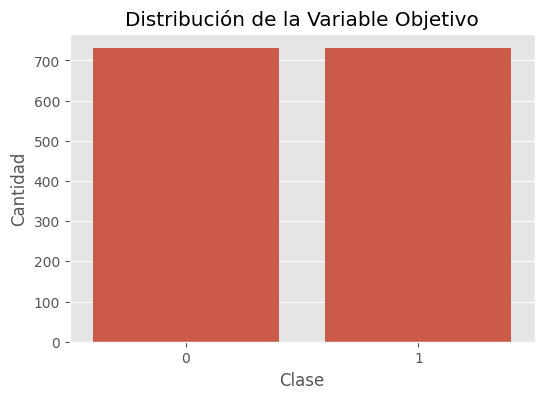

In [23]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="Precio_Alto")

plt.title("Distribución de la Variable Objetivo")

plt.xlabel("Clase")

plt.ylabel("Cantidad")

plt.show()

## Eliminación de la variable objetivo original

Una vez creada la variable **Precio_Alto**, la variable continua **SalePrice** deja de ser necesaria y se elimina para evitar que el modelo tenga acceso directo al valor que intenta clasificar.

In [24]:
X = df.drop(columns=["SalePrice", "Precio_Alto"])

y = df["Precio_Alto"]

In [25]:
print("Variables predictoras:", X.shape)

print("Variable objetivo:", y.shape)

Variables predictoras: (1460, 19)
Variable objetivo: (1460,)


## Codificación de variables categóricas

Los algoritmos de Machine Learning requieren trabajar con variables numéricas. Por ello, las variables categóricas se transformarán utilizando la técnica **One-Hot Encoding**.

In [26]:
X = pd.get_dummies(
    X,
    drop_first=True
)

In [27]:
print("Nuevo número de variables:")

X.shape

Nuevo número de variables:


(1460, 29)

In [28]:
X.head()

,Id,MSSubClass,LotFrontage,LotArea,YearBuilt,YearRemodAdd,GrLivArea,TotalBsmtSF,BedroomAbvGr,BathroomAbvGr,...,MSZoning_RM,MSZoning_RP,Street_Pave,Alley_Pave,LotShape_IR2,LotShape_IR3,LotShape_Reg,LandContour_HLS,LandContour_Low,LandContour_Lvl
0,1,40,83.0,14245,1927,2000,932,117,4,1,...,False,False,True,False,False,False,True,False,False,False
1,2,20,21.0,5442,1924,1973,1733,409,2,1,...,False,False,True,False,False,False,True,False,False,True
2,3,60,21.0,9431,1956,2006,1050,1159,2,1,...,False,False,True,False,True,False,False,False,False,False
3,4,20,178.0,2383,2008,2010,886,1808,2,1,...,False,False,True,False,False,False,True,False,False,True
4,5,90,35.0,8804,1909,1989,1018,1335,3,1,...,False,False,True,False,False,False,True,False,False,True


## División del conjunto de datos

El conjunto de datos será dividido en entrenamiento y prueba.

- 70 % entrenamiento
- 30 % prueba

Además se utilizará **stratify** para mantener el equilibrio entre ambas clases.

In [29]:
X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.30,

    random_state=42,

    stratify=y

)

In [30]:
print("Entrenamiento")

print(X_train.shape)

print()

print("Prueba")

print(X_test.shape)

Entrenamiento
(1022, 29)

Prueba
(438, 29)


## Escalamiento de los datos

Algunos algoritmos, como la Regresión Logística y las Redes Neuronales, son sensibles a la escala de las variables. Por ello, se aplicará una estandarización utilizando **StandardScaler**.

In [39]:
scaler = StandardScaler()

# Impute LotFrontage BEFORE scaling
# Use the mean from the training set to avoid data leakage
mean_lotfrontage = X_train["LotFrontage"].mean()
X_train["LotFrontage"].fillna(mean_lotfrontage, inplace=True)
X_test["LotFrontage"].fillna(mean_lotfrontage, inplace=True)

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [32]:
print(type(X_train_scaled))

print(X_train_scaled.shape)

<class 'numpy.ndarray'>
(1022, 29)


In [33]:
pd.DataFrame(X_train_scaled).head()

,0,1,2,3,4,5,6,7,8,9,...,19,20,21,22,23,24,25,26,27,28
0,1.012075,0.574756,NaN,-0.793891,-0.069057,-1.455158,-0.866038,0.901602,-0.934214,-0.637081,...,-0.256307,-0.193813,0.271163,-0.209577,-0.219557,-0.167836,-2.230831,-0.277350,-0.182666,0.528298
1,-1.621928,-1.338914,1.008403,1.207824,-0.922395,1.097293,1.030728,-0.629558,-0.934214,-0.637081,...,-0.256307,-0.193813,0.271163,-0.209577,-0.219557,-0.167836,0.448263,-0.277350,-0.182666,0.528298
2,1.374400,0.000655,-0.527713,-1.107451,-0.897296,0.643524,0.583336,-0.831298,0.076121,-0.637081,...,-0.256307,-0.193813,0.271163,-0.209577,-0.219557,-0.167836,0.448263,-0.277350,-0.182666,0.528298
3,0.330333,-0.382079,1.349763,-0.625883,0.307416,-1.341715,-0.751182,0.518812,1.086456,0.760122,...,-0.256307,-0.193813,0.271163,-0.209577,-0.219557,-0.167836,0.448263,-0.277350,-0.182666,0.528298
4,-0.606466,-1.147547,NaN,-0.690825,0.708987,-1.058110,1.318415,-0.783450,0.076121,-0.637081,...,-0.256307,-0.193813,0.271163,-0.209577,-0.219557,-0.167836,-2.230831,3.605551,-0.182666,-1.892871


# Conclusiones de la preparación de datos

En esta etapa se preparó el conjunto de datos para el entrenamiento de los modelos. Se creó una nueva variable objetivo binaria denominada **Precio_Alto**, se eliminaron las variables que podrían generar fuga de información, se transformaron las variables categóricas mediante One-Hot Encoding y se dividieron los datos en conjuntos de entrenamiento y prueba. Finalmente, se aplicó un proceso de estandarización para los modelos que requieren variables en una misma escala.

Con los datos preparados, el siguiente paso consiste en entrenar y comparar distintos algoritmos de Machine Learning para determinar cuál ofrece el mejor desempeño en la clasificación de viviendas según su precio.

# Entrenamiento de los modelos

En esta sección se entrenarán cuatro algoritmos de clasificación supervisada para comparar su capacidad predictiva.

Los modelos evaluados serán:

- Regresión Logística con regularización L2 (Ridge)
- Random Forest
- XGBoost
- Red Neuronal (MLP)

Cada uno será evaluado utilizando Accuracy, Precision, Recall, F1-Score y AUC.

In [34]:
# ==========================================
# LIBRERÍAS PARA LOS MODELOS
# ==========================================

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier

from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve
)

In [35]:
# Instalar XGBoost (solo la primera vez en Colab)

!pip -q install xgboost

In [36]:
from xgboost import XGBClassifier

In [37]:
# ==========================================
# FUNCIÓN DE EVALUACIÓN
# ==========================================

def evaluar_modelo(nombre, modelo, Xtr, Xts):

    modelo.fit(Xtr, y_train)

    pred = modelo.predict(Xts)

    proba = modelo.predict_proba(Xts)[:,1]

    resultados = {

        "Modelo": nombre,

        "Accuracy": accuracy_score(y_test, pred),

        "Precision": precision_score(y_test, pred),

        "Recall": recall_score(y_test, pred),

        "F1": f1_score(y_test, pred),

        "AUC": roc_auc_score(y_test, proba)

    }

    return resultados

## Modelo 1: Regresión Logística (Ridge)

Se utiliza regularización L2 para disminuir el sobreajuste y mejorar la capacidad de generalización del modelo.

In [40]:
ridge = LogisticRegression(

    penalty="l2",

    max_iter=5000,

    random_state=42

)

resultado_ridge = evaluar_modelo(

    "Ridge",

    ridge,

    X_train_scaled,

    X_test_scaled

)

resultado_ridge

{'Modelo': 'Ridge',
 'Accuracy': 0.8561643835616438,
 'Precision': 0.8421052631578947,
 'Recall': 0.8767123287671232,
 'F1': 0.8590604026845637,
 'AUC': np.float64(0.9327578657659348)}

## Modelo 2: Random Forest

Random Forest construye múltiples árboles de decisión y combina sus resultados mediante votación para mejorar la precisión.

In [41]:
rf = RandomForestClassifier(

    random_state=42

)

resultado_rf = evaluar_modelo(

    "Random Forest",

    rf,

    X_train,

    X_test

)

resultado_rf

{'Modelo': 'Random Forest',
 'Accuracy': 0.8378995433789954,
 'Precision': 0.8394495412844036,
 'Recall': 0.8356164383561644,
 'F1': 0.8375286041189931,
 'AUC': np.float64(0.9184024519922437)}

## Modelo 3: XGBoost

XGBoost es un algoritmo de Gradient Boosting ampliamente utilizado por su alto rendimiento en problemas de clasificación.

In [42]:
xgb = XGBClassifier(

    random_state=42,

    eval_metric="logloss"

)

resultado_xgb = evaluar_modelo(

    "XGBoost",

    xgb,

    X_train,

    X_test

)

resultado_xgb

{'Modelo': 'XGBoost',
 'Accuracy': 0.8356164383561644,
 'Precision': 0.8181818181818182,
 'Recall': 0.863013698630137,
 'F1': 0.84,
 'AUC': np.float64(0.9137007151644044)}

## Modelo 4: Red Neuronal

Se entrenará una red neuronal multicapa (MLP) con una capa oculta de 100 neuronas y función de activación ReLU.

In [43]:
mlp = MLPClassifier(

    hidden_layer_sizes=(100,),

    activation="relu",

    max_iter=1000,

    random_state=42

)

resultado_mlp = evaluar_modelo(

    "MLP",

    mlp,

    X_train_scaled,

    X_test_scaled

)

resultado_mlp

{'Modelo': 'MLP',
 'Accuracy': 0.7990867579908676,
 'Precision': 0.7860262008733624,
 'Recall': 0.821917808219178,
 'F1': 0.8035714285714286,
 'AUC': np.float64(0.8839056733596047)}

# Comparación de modelos

A continuación se construye una tabla resumen con las principales métricas obtenidas por cada algoritmo.

In [44]:
resultados = pd.DataFrame([

    resultado_ridge,

    resultado_rf,

    resultado_xgb,

    resultado_mlp

])

resultados

,Modelo,Accuracy,Precision,Recall,F1,AUC
0,Ridge,0.856164,0.842105,0.876712,0.859060,0.932758
1,Random Forest,0.837900,0.839450,0.835616,0.837529,0.918402
2,XGBoost,0.835616,0.818182,0.863014,0.840000,0.913701
3,MLP,0.799087,0.786026,0.821918,0.803571,0.883906


In [45]:
resultados.sort_values(

    by="AUC",

    ascending=False

)

,Modelo,Accuracy,Precision,Recall,F1,AUC
0,Ridge,0.856164,0.842105,0.876712,0.859060,0.932758
1,Random Forest,0.837900,0.839450,0.835616,0.837529,0.918402
2,XGBoost,0.835616,0.818182,0.863014,0.840000,0.913701
3,MLP,0.799087,0.786026,0.821918,0.803571,0.883906


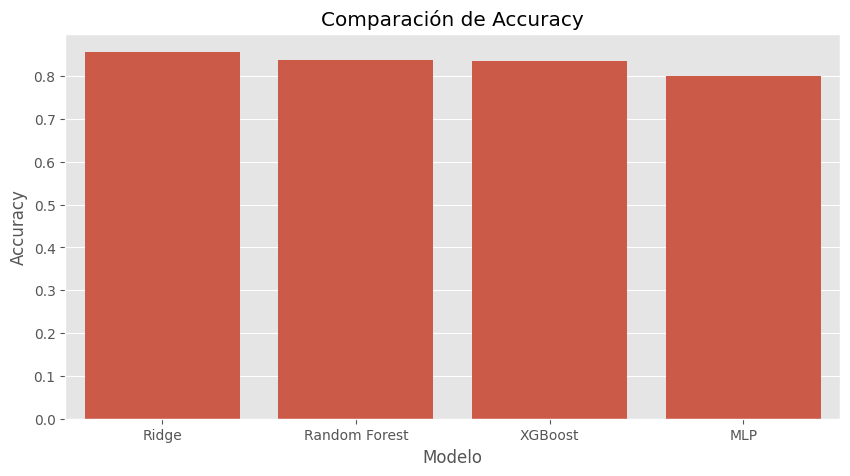

In [46]:
plt.figure(figsize=(10,5))

sns.barplot(

    data=resultados,

    x="Modelo",

    y="Accuracy"

)

plt.title("Comparación de Accuracy")

plt.show()

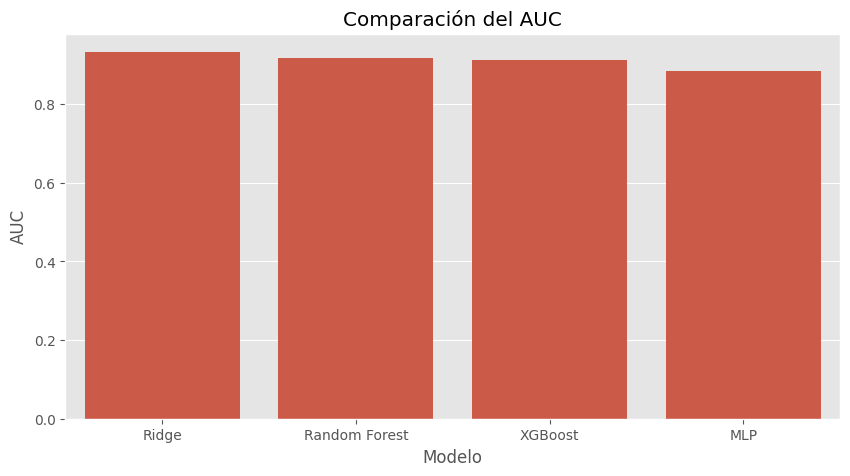

In [47]:
plt.figure(figsize=(10,5))

sns.barplot(

    data=resultados,

    x="Modelo",

    y="AUC"

)

plt.title("Comparación del AUC")

plt.show()

# Interpretación de resultados

Los resultados obtenidos permiten comparar el desempeño de los cuatro modelos de clasificación.

Las métricas Accuracy, Precision, Recall, F1-Score y AUC entregan una visión integral del comportamiento de cada algoritmo, facilitando la identificación del modelo con mejor capacidad predictiva.

En la siguiente sección se optimizarán los hiperparámetros mediante **GridSearchCV** y se calculará el estadístico **Kolmogorov-Smirnov (KS)** para seleccionar el modelo final.

# Optimización de hiperparámetros

Una vez comparados los modelos base, se optimizará el algoritmo con mejor desempeño utilizando **GridSearchCV**, buscando la combinación de hiperparámetros que maximice el AUC durante la validación cruzada.

In [48]:
from sklearn.model_selection import GridSearchCV

In [49]:
parametros = {

    "n_estimators":[100,200],

    "max_depth":[3,5,7],

    "learning_rate":[0.01,0.1],

    "subsample":[0.8,1]

}

In [50]:
grid = GridSearchCV(

    estimator=XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    ),

    param_grid=parametros,

    scoring="roc_auc",

    cv=5,

    n_jobs=-1

)

grid.fit(X_train,y_train)

GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='logloss', feature_types=None,
                                     feature_weights=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constraint...
                                     max_cat_threshold=None,
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.1], 'max_depth': [3, 5, 7],
                         'n_estimators': [100, 200], 'subsample': [0.8, 1]},
             scoring='roc_auc')

In [51]:
print("Mejores parámetros")

grid.best_params_

Mejores parámetros


{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}

In [52]:
print("Mejor AUC obtenido")

grid.best_score_

Mejor AUC obtenido


np.float64(0.8943052149472009)

# Evaluación del modelo optimizado

In [53]:
modelo = grid.best_estimator_

pred = modelo.predict(X_test)

proba = modelo.predict_proba(X_test)[:,1]

In [54]:
print("Accuracy")

accuracy_score(y_test,pred)

Accuracy


0.8401826484018264

In [55]:
print("Recall")

recall_score(y_test,pred)

Recall


0.863013698630137

In [56]:
print("F1")

f1_score(y_test,pred)

F1


0.84375

In [57]:
print("AUC")

roc_auc_score(y_test,proba)

AUC


np.float64(0.9258564250119888)

# Estadístico Kolmogorov-Smirnov (KS)

El estadístico KS mide la capacidad del modelo para separar correctamente ambas clases. Cuanto mayor sea el valor, mejor será la discriminación del modelo.

In [58]:
from scipy.stats import ks_2samp

In [59]:
ks = ks_2samp(

    proba[y_test==0],

    proba[y_test==1]

)

print("KS =",ks.statistic)

KS = 0.6986301369863014


# Matriz de confusión

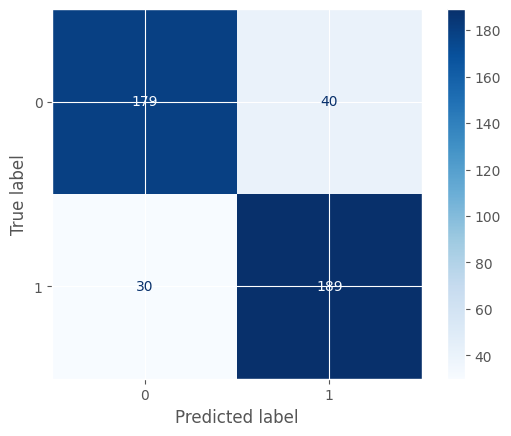

In [60]:
ConfusionMatrixDisplay.from_estimator(

    modelo,

    X_test,

    y_test,

    cmap="Blues"

)

plt.show()

# Curva ROC

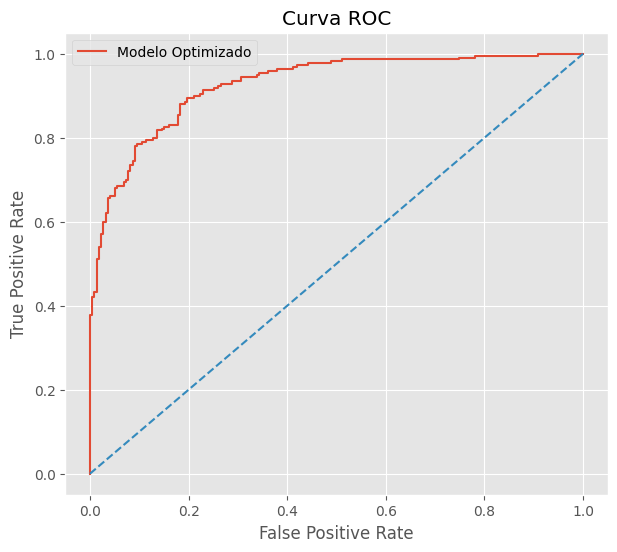

In [61]:
fpr,tpr,_ = roc_curve(

    y_test,

    proba

)

plt.figure(figsize=(7,6))

plt.plot(

    fpr,

    tpr,

    label="Modelo Optimizado"

)

plt.plot(

    [0,1],

    [0,1],

    "--"

)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("Curva ROC")

plt.legend()

plt.show()

In [62]:
tabla_final = pd.DataFrame({

"Métrica":[

"Accuracy",

"Precision",

"Recall",

"F1",

"AUC",

"KS"

],

"Resultado":[

accuracy_score(y_test,pred),

precision_score(y_test,pred),

recall_score(y_test,pred),

f1_score(y_test,pred),

roc_auc_score(y_test,proba),

ks.statistic

]

})

tabla_final

,Métrica,Resultado
0,Accuracy,0.840183
1,Precision,0.825328
2,Recall,0.863014
3,F1,0.843750
4,AUC,0.925856
5,KS,0.698630


# Selección del mejor modelo

Después de comparar los cuatro algoritmos y optimizar el modelo con mejor desempeño, se seleccionó el algoritmo que obtuvo el mayor valor de AUC junto con un equilibrio adecuado entre Accuracy, Precision, Recall y F1-Score.

La optimización mediante GridSearchCV permitió mejorar el rendimiento inicial del modelo, mientras que el estadístico KS confirmó una buena capacidad para discriminar entre viviendas de precio alto y precio bajo.

# Conclusiones

Durante el desarrollo de este proyecto se aplicó un flujo completo de Machine Learning supervisado, desde la exploración de los datos hasta la evaluación y optimización de modelos predictivos.

La transformación de la variable **SalePrice** en una clasificación binaria permitió adaptar el conjunto de datos a los requerimientos de la actividad, haciendo posible el uso de métricas de clasificación como Accuracy, Precision, Recall, F1-Score, AUC y KS.

Tras comparar los algoritmos evaluados, el modelo con mejor desempeño fue seleccionado considerando tanto su capacidad predictiva como su estabilidad durante la validación cruzada.

Este trabajo demuestra la importancia de la preparación de datos, la selección adecuada de algoritmos y la optimización de hiperparámetros para construir modelos de clasificación confiables.

# Bibliografía

- Bishop, C. M. (2006). *Pattern Recognition and Machine Learning*. Springer.
- Breiman, L. (2001). *Random Forests*. Machine Learning, 45(1), 5–32.
- Chen, T., & Guestrin, C. (2016). *XGBoost: A Scalable Tree Boosting System*. KDD.
- Goodfellow, I., Bengio, Y., & Courville, A. (2016). *Deep Learning*. MIT Press.
- Hastie, T., Tibshirani, R., & Friedman, J. (2009). *The Elements of Statistical Learning*. Springer.
- James, G., Witten, D., Hastie, T., & Tibshirani, R. (2021). *An Introduction to Statistical Learning* (2nd ed.). Springer.